## 1 - Packages

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import json
import warnings
warnings.filterwarnings('ignore')
from time import time

%matplotlib inline

print("Packages imported successfully!")

Packages imported successfully!


## 2 - Load Preprocessed Data

In [9]:
# Load preprocessed data
X = joblib.load('../data/processed/X_vectorized.pkl')
Y = joblib.load('../data/processed/Y_labels.pkl')
vectorizer = joblib.load('../data/processed/vectorizer.pkl')
label_encoder = joblib.load('../data/processed/label_encoder.pkl')

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"\nSparse matrix format: {type(X)}")

X shape: (8462, 90493)
Y shape: (8462,)
Number of features: 90493
Number of samples: 8462

Sparse matrix format: <class 'scipy.sparse._csr.csr_matrix'>


## 3 - Prepare Binary Dimensions

In [10]:
# Extract binary labels for each dimension
personality_types = label_encoder.inverse_transform(Y)

dimensions = {
    'I/E': np.array([1 if pt[0] == 'I' else 0 for pt in personality_types]),
    'N/S': np.array([1 if pt[1] == 'N' else 0 for pt in personality_types]),
    'T/F': np.array([1 if pt[2] == 'T' else 0 for pt in personality_types]),
    'J/P': np.array([1 if pt[3] == 'J' else 0 for pt in personality_types])
}

# Print distributions
print("=" * 60)
print("DIMENSION DISTRIBUTIONS")
print("=" * 60)
for dim_name, labels in dimensions.items():
    pos_class = dim_name.split('/')[0]
    neg_class = dim_name.split('/')[1]
    n_pos = np.sum(labels == 1)
    n_neg = np.sum(labels == 0)
    pct_pos = 100 * n_pos / len(labels)
    print(f"{dim_name}: {pos_class}={n_pos} ({pct_pos:.1f}%), {neg_class}={n_neg} ({100-pct_pos:.1f}%)")
print("=" * 60)

DIMENSION DISTRIBUTIONS
I/E: I=6534 (77.2%), E=1928 (22.8%)
N/S: N=7284 (86.1%), S=1178 (13.9%)
T/F: T=3907 (46.2%), F=4555 (53.8%)
J/P: J=3365 (39.8%), P=5097 (60.2%)


## 4 - GridSearchCV Configuration

**Parameter Grid (OPTIMIZED FOR SPEED):**
- **C**: [0.001, 0.01, 0.1, 1.0, 10.0] - 5 values
- **penalty**: ['l1', 'l2'] - 2 regularization types
- **solver**: Automatically matched to penalty:
  - L1: 'liblinear' or 'saga'
  - L2: 'lbfgs' (default, fast)
- **class_weight**: [None, 'balanced'] - 2 options

**Total combinations per dimension:**
- L2 penalty: 5 C × 2 class_weight = 10 combinations
- L1 penalty: 5 C × 2 class_weight = 10 combinations
- **Total: 20 combinations** (much faster than SVM!)

**Cross-Validation:**
- 5-fold StratifiedKFold (preserves class proportions)
- Scoring: F1-score (better for imbalanced data)

## 4.1 - Understanding Logistic Regression Hyperparameters

### Quick Overview

**C (Regularization Strength)**: Controls the trade-off between fitting the training data and keeping the model simple. Defined as $C = 1/\lambda$ where $\lambda$ is the regularization strength. Small C (e.g., 0.001) means strong regularization → simple model that may underfit. Large C (e.g., 10.0) means weak regularization → complex model that may overfit. We test [0.001, 0.01, 0.1, 1.0, 10.0] to find the sweet spot.

**penalty (L1 vs L2)**: Determines how coefficients are penalized. L2 (Ridge) uses $\sum w_j^2$ and shrinks all coefficients proportionally, keeping all features with small weights. L1 (Lasso) uses $\sum |w_j|$ and forces many coefficients to exactly zero, performing automatic feature selection. For text data with thousands of features, L2 typically works well unless you specifically want sparse models.

**solver (Optimization Algorithm)**: The mathematical method to minimize the cost function. We use 'lbfgs' for L2 (fast quasi-Newton method, excellent for medium-large datasets) and 'liblinear' for L1 (coordinate descent, required for L1 penalty). Both are efficient for our ~8000 samples with 5000+ TF-IDF features.

**class_weight (Handle Imbalance)**: Adjusts the importance of each class in the loss function using $w_c = \frac{n_{samples}}{n_{classes} \times n_{samples\_in\_class\_c}}$. With 'balanced', minority classes get higher weights to force the model to learn both classes. Without it (None), models become "lazy" and just predict the majority class (76% accuracy but 7% specificity). This is why we test both options - balanced typically wins for imbalanced MBTI data.

**GridSearchCV Strategy**: We test 20 combinations per dimension (5 C values × 2 penalties × 2 class_weights) using 5-fold cross-validation with F1-score as the metric. All experiments use upsampling via Pipeline to prevent data leakage, ensuring balanced training within each fold.

In [11]:
# Configuration
RANDOM_STATE = 42
MAX_ITER = 1000
N_JOBS = -1  # Use all CPU cores

# Define parameter grids for different penalty types
# Note: solver must be compatible with penalty
param_grids = {
    'l2': {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'penalty': ['l2'],
        'solver': ['lbfgs'],  # Fast solver for L2
        'class_weight': [None, 'balanced']
    },
    'l1': {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'penalty': ['l1'],
        'solver': ['liblinear'],  # Required for L1 with small datasets
        'class_weight': [None, 'balanced']
    }
}

# Cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Configuration complete! (OPTIMIZED FOR SPEED)")
print(f"\nL2 penalty: {len(param_grids['l2']['C'])} C × {len(param_grids['l2']['class_weight'])} class_weight = {len(param_grids['l2']['C']) * len(param_grids['l2']['class_weight'])} combinations")
print(f"L1 penalty: {len(param_grids['l1']['C'])} C × {len(param_grids['l1']['class_weight'])} class_weight = {len(param_grids['l1']['C']) * len(param_grids['l1']['class_weight'])} combinations")
print(f"\nTotal per dimension: {sum(len(pg['C']) * len(pg['class_weight']) for pg in param_grids.values())} combinations")
print("\n⚡ This should be MUCH faster than SVM!")

Configuration complete! (OPTIMIZED FOR SPEED)

L2 penalty: 5 C × 2 class_weight = 10 combinations
L1 penalty: 5 C × 2 class_weight = 10 combinations

Total per dimension: 20 combinations

⚡ This should be MUCH faster than SVM!


In [12]:
# Store all results (only with upsampling)
all_results = []

print("=" * 80)
print("NOTE: Only testing with upsampling (upsampling is essential for imbalanced data)")
print("      Without upsampling, models become 'lazy' and only predict majority class")
print("=" * 80)

NOTE: Only testing with upsampling (upsampling is essential for imbalanced data)
      Without upsampling, models become 'lazy' and only predict majority class


## 5 - Hyperparameter Tuning (With Upsampling)

**Testing with RandomOverSampler inside a Pipeline to handle class imbalance.**

- Pipeline ensures upsampling happens inside each CV fold (prevents data leakage)

Upsampling is essential for MBTI classification because:- With it: Balanced performance with both good recall and specificity (~40-50%)
- Without it: Models achieve high accuracy (~76%) but terrible specificity (~7%) → "lazy model"

In [13]:
print("=" * 80)
print("STARTING HYPERPARAMETER TUNING (With Upsampling)")
print("=" * 80)
print("Note: Using Pipeline to prevent data leakage (upsampling happens inside each CV fold)")
print("=" * 80)

for dim_name, Y_binary in dimensions.items():
    print(f"\n{'=' * 80}")
    print(f"DIMENSION: {dim_name}")
    print("=" * 80)
    
    # Split data once (80/20 train/test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
    
    # Test each penalty type
    for penalty_name, param_grid in param_grids.items():
        print(f"\n  Testing {penalty_name.upper()} penalty with upsampling...")
        start_time = time()
        
        # Create pipeline with upsampling + Logistic Regression
        pipeline = ImbPipeline([
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('classifier', LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE))
        ])
        
        # Adjust parameter grid for pipeline (need 'classifier__' prefix)
        pipeline_param_grid = {f'classifier__{key}': value for key, value in param_grid.items()}
        
        # GridSearchCV
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=pipeline_param_grid,
            cv=cv,
            scoring='f1',
            n_jobs=N_JOBS,
            verbose=0,
            return_train_score=True
        )
        
        grid_search.fit(X_train, y_train)
        elapsed = time() - start_time
        
        # Get best model
        best_pipeline = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_cv_score = grid_search.best_score_
        
        # Extract actual params (remove 'classifier__' prefix)
        actual_params = {key.replace('classifier__', ''): value for key, value in best_params.items()}
        
        # Evaluate on test set
        y_pred = best_pipeline.predict(X_test)
        test_accuracy = accuracy_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred, zero_division=0)
        test_precision = precision_score(y_test, y_pred, zero_division=0)
        test_recall = recall_score(y_test, y_pred, zero_division=0)
        
        # Store results
        result = {
            'dimension': dim_name,
            'penalty': penalty_name,
            'upsampling': True,
            'best_C': actual_params['C'],
            'best_solver': actual_params['solver'],
            'best_class_weight': actual_params['class_weight'],
            'cv_f1_score': best_cv_score,
            'test_accuracy': test_accuracy,
            'test_f1_score': test_f1,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'fit_time_seconds': elapsed
        }
        all_results.append(result)
        
        print(f"    Best params: C={actual_params['C']}, class_weight={actual_params['class_weight']}")
        print(f"    CV F1: {best_cv_score:.4f}")
        print(f"    Test F1: {test_f1:.4f} | Test Acc: {test_accuracy:.4f}")
        print(f"    Time: {elapsed:.1f}s")

print(f"\n{'=' * 80}")
print("✅ HYPERPARAMETER TUNING COMPLETE (With Upsampling)")
print("=" * 80)

STARTING HYPERPARAMETER TUNING (With Upsampling)
Note: Using Pipeline to prevent data leakage (upsampling happens inside each CV fold)

DIMENSION: I/E
Train size: 6769, Test size: 1693

  Testing L2 penalty with upsampling...
    Best params: C=10.0, class_weight=None
    CV F1: 0.8455
    Test F1: 0.8395 | Test Acc: 0.7454
    Time: 14.3s

  Testing L1 penalty with upsampling...
    Best params: C=10.0, class_weight=None
    CV F1: 0.8191
    Test F1: 0.8150 | Test Acc: 0.7165
    Time: 21.2s

DIMENSION: N/S
Train size: 6769, Test size: 1693

  Testing L2 penalty with upsampling...
    Best params: C=10.0, class_weight=None
    CV F1: 0.9068
    Test F1: 0.9126 | Test Acc: 0.8470
    Time: 10.7s

  Testing L1 penalty with upsampling...
    Best params: C=10.0, class_weight=None
    CV F1: 0.8826
    Test F1: 0.8869 | Test Acc: 0.8069
    Time: 26.8s

DIMENSION: T/F
Train size: 6769, Test size: 1693

  Testing L2 penalty with upsampling...
    Best params: C=10.0, class_weight=None
   

## 6 - Results Summary (DataFrame)

In [14]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Verify all results are upsampled
print("=" * 100)
print("RESULTS SUMMARY (All with Upsampling)")
print("=" * 100)
print(f"Total configurations tested: {len(results_df)}")
print(f"All results use upsampling: {results_df['upsampling'].all()}")
print("=" * 100)

# Round numerical columns for readability
numerical_cols = ['cv_f1_score', 'test_accuracy', 'test_f1_score', 'test_precision', 'test_recall', 'fit_time_seconds']
results_df[numerical_cols] = results_df[numerical_cols].round(4)

# Sort by dimension and test F1 score
results_df = results_df.sort_values(['dimension', 'test_f1_score'], ascending=[True, False])

print("\n" + "=" * 100)
print("DETAILED RESULTS")
print("=" * 100)
display(results_df)

# Save to CSV
results_df.to_csv('logistic_regression_hyperparameter_tuning_results.csv', index=False)
print("\n✅ Results saved to 'logistic_regression_hyperparameter_tuning_results.csv'")

RESULTS SUMMARY (All with Upsampling)
Total configurations tested: 8
All results use upsampling: True

DETAILED RESULTS


,dimension,penalty,upsampling,best_C,best_solver,best_class_weight,cv_f1_score,test_accuracy,test_f1_score,test_precision,test_recall,fit_time_seconds
0,I/E,l2,True,10.0,lbfgs,None,0.8455,0.7454,0.8395,0.8179,0.8623,14.3295
1,I/E,l1,True,10.0,liblinear,None,0.8191,0.7165,0.8150,0.8213,0.8087,21.1542
7,J/P,l1,True,1.0,liblinear,None,0.5297,0.5972,0.5465,0.4946,0.6107,14.9553
6,J/P,l2,True,1.0,lbfgs,None,0.5365,0.6208,0.5251,0.5228,0.5275,5.7706
2,N/S,l2,True,10.0,lbfgs,None,0.9068,0.8470,0.9126,0.8977,0.9279,10.7080
3,N/S,l1,True,10.0,liblinear,None,0.8826,0.8069,0.8869,0.8940,0.8799,26.7502
4,T/F,l2,True,10.0,lbfgs,None,0.7440,0.7643,0.7489,0.7373,0.7609,9.2461
5,T/F,l1,True,10.0,liblinear,None,0.7102,0.7342,0.7104,0.7150,0.7059,11.3949



✅ Results saved to 'logistic_regression_hyperparameter_tuning_results.csv'


## 7 - Best Model per Dimension

In [15]:
# Find best model for each dimension (by test F1 score)
best_models = results_df.loc[results_df.groupby('dimension')['test_f1_score'].idxmax()]

print("=" * 100)
print("BEST MODEL PER DIMENSION (Highest Test F1-Score)")
print("=" * 100)
display(best_models[['dimension', 'penalty', 'upsampling', 'best_C', 'best_solver', 
                      'best_class_weight', 'cv_f1_score', 'test_f1_score', 'test_accuracy', 
                      'test_recall', 'fit_time_seconds']])

print("\n" + "=" * 100)
print("KEY INSIGHTS (All models use upsampling):")
print("=" * 100)
for idx, row in best_models.iterrows():
    print(f"\n{row['dimension']}:")
    print(f"  Best penalty: {row['penalty'].upper()}")
    print(f"  Upsampling: ✅ Yes (essential for handling class imbalance)")
    print(f"  C = {row['best_C']}")
    print(f"  class_weight = {row['best_class_weight']}")
    print(f"  solver = {row['best_solver']}")
    print(f"  Test F1: {row['test_f1_score']:.4f}")
    print(f"  Test Accuracy: {row['test_accuracy']:.4f}")
    print(f"  Test Recall: {row['test_recall']:.4f}")

BEST MODEL PER DIMENSION (Highest Test F1-Score)


,dimension,penalty,upsampling,best_C,best_solver,best_class_weight,cv_f1_score,test_f1_score,test_accuracy,test_recall,fit_time_seconds
0,I/E,l2,True,10.0,lbfgs,None,0.8455,0.8395,0.7454,0.8623,14.3295
7,J/P,l1,True,1.0,liblinear,None,0.5297,0.5465,0.5972,0.6107,14.9553
2,N/S,l2,True,10.0,lbfgs,None,0.9068,0.9126,0.8470,0.9279,10.7080
4,T/F,l2,True,10.0,lbfgs,None,0.7440,0.7489,0.7643,0.7609,9.2461



KEY INSIGHTS (All models use upsampling):

I/E:
  Best penalty: L2
  Upsampling: ✅ Yes (essential for handling class imbalance)
  C = 10.0
  class_weight = None
  solver = lbfgs
  Test F1: 0.8395
  Test Accuracy: 0.7454
  Test Recall: 0.8623

J/P:
  Best penalty: L1
  Upsampling: ✅ Yes (essential for handling class imbalance)
  C = 1.0
  class_weight = None
  solver = liblinear
  Test F1: 0.5465
  Test Accuracy: 0.5972
  Test Recall: 0.6107

N/S:
  Best penalty: L2
  Upsampling: ✅ Yes (essential for handling class imbalance)
  C = 10.0
  class_weight = None
  solver = lbfgs
  Test F1: 0.9126
  Test Accuracy: 0.8470
  Test Recall: 0.9279

T/F:
  Best penalty: L2
  Upsampling: ✅ Yes (essential for handling class imbalance)
  C = 10.0
  class_weight = None
  solver = lbfgs
  Test F1: 0.7489
  Test Accuracy: 0.7643
  Test Recall: 0.7609


## 8 - Export Optimal Parameters (JSON)

**This is the most important output!** Save optimal hyperparameters to JSON file for use in main analysis notebook.

All exported parameters include upsampling as they consistently achieve better F1-scores and balanced performance.

In [16]:
# Create dictionary of optimal hyperparameters for each dimension
optimal_params = {}

for idx, row in best_models.iterrows():
    optimal_params[row['dimension']] = {
        'C': float(row['best_C']),  # Convert to native Python float
        'penalty': row['penalty'],
        'solver': row['best_solver'],
        'class_weight': row['best_class_weight'],
        'max_iter': MAX_ITER,
        'random_state': RANDOM_STATE,
        'upsampling': bool(row['upsampling']),
        # Performance metrics for reference
        'expected_test_f1': float(row['test_f1_score']),
        'expected_test_accuracy': float(row['test_accuracy'])
    }

# Save to JSON
with open('../models/optimal_hyperparameters_lr.json', 'w') as f:
    json.dump(optimal_params, f, indent=2)

print("=" * 100)
print("✅ OPTIMAL HYPERPARAMETERS EXPORTED")
print("=" * 100)
print("\nSaved to: ../models/optimal_hyperparameters_lr.json")
print("\nContents:")
print(json.dumps(optimal_params, indent=2))
print("\n" + "=" * 100)
print("📝 USE THESE PARAMETERS IN YOUR MAIN NOTEBOOK!")
print("=" * 100)

✅ OPTIMAL HYPERPARAMETERS EXPORTED

Saved to: ../models/optimal_hyperparameters_lr.json

Contents:
{
  "I/E": {
    "C": 10.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "class_weight": null,
    "max_iter": 1000,
    "random_state": 42,
    "upsampling": true,
    "expected_test_f1": 0.8395,
    "expected_test_accuracy": 0.7454
  },
  "J/P": {
    "C": 1.0,
    "penalty": "l1",
    "solver": "liblinear",
    "class_weight": null,
    "max_iter": 1000,
    "random_state": 42,
    "upsampling": true,
    "expected_test_f1": 0.5465,
    "expected_test_accuracy": 0.5972
  },
  "N/S": {
    "C": 10.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "class_weight": null,
    "max_iter": 1000,
    "random_state": 42,
    "upsampling": true,
    "expected_test_f1": 0.9126,
    "expected_test_accuracy": 0.847
  },
  "T/F": {
    "C": 10.0,
    "penalty": "l2",
    "solver": "lbfgs",
    "class_weight": null,
    "max_iter": 1000,
    "random_state": 42,
    "upsampling": true,
    "expect

## 9 - Alternative: Generalization-Aware Selection

**Standard approach optimizes for maximum CV F1-score.**

**Generalization-aware approach:** Select hyperparameters that balance F1-score with low overfitting gap.

Formula: `generalization_score = cv_f1 - penalty * (train_f1 - cv_f1)`

Where penalty determines how much we care about overfitting (0.3-0.5 recommended for new data scenarios).

In [17]:
print("=" * 100)
print("GENERALIZATION-AWARE HYPERPARAMETER SELECTION")
print("=" * 100)
print("Standard approach: Select model with highest CV F1-score")
print("Generalization-aware: Balance CV F1-score with low overfitting gap")
print("=" * 100)

# We need to re-run GridSearchCV to get train scores for each configuration
# This time we'll extract CV results to compute overfitting gaps

generalization_results = []
PENALTY_FACTOR = 0.5  # How much to penalize overfitting (0.3-0.5 recommended)

print(f"\nUsing penalty factor: {PENALTY_FACTOR}")
print("Score = CV_F1 - {:.1f} × (Train_F1 - CV_F1)".format(PENALTY_FACTOR))
print("=" * 100)

for dim_name, Y_binary in dimensions.items():
    print(f"\n{'=' * 100}")
    print(f"DIMENSION: {dim_name}")
    print("=" * 100)
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, Y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=Y_binary
    )
    
    # Test each penalty type
    for penalty_name, param_grid in param_grids.items():
        print(f"\n  Analyzing {penalty_name.upper()} penalty...")
        
        # Create pipeline
        pipeline = ImbPipeline([
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('classifier', LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE))
        ])
        
        # Adjust parameter grid for pipeline
        pipeline_param_grid = {f'classifier__{key}': value for key, value in param_grid.items()}
        
        # GridSearchCV with train scores
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=pipeline_param_grid,
            cv=cv,
            scoring='f1',
            n_jobs=N_JOBS,
            verbose=0,
            return_train_score=True  # KEY: Get train scores for overfitting analysis
        )
        
        grid_search.fit(X_train, y_train)
        
        # Extract CV results
        cv_results = pd.DataFrame(grid_search.cv_results_)
        
        # Calculate generalization score for each configuration
        cv_results['mean_overfit_gap'] = cv_results['mean_train_score'] - cv_results['mean_test_score']
        cv_results['generalization_score'] = (
            cv_results['mean_test_score'] - 
            PENALTY_FACTOR * cv_results['mean_overfit_gap'].clip(lower=0)
        )
        
        # Standard selection: highest CV F1
        standard_idx = cv_results['mean_test_score'].idxmax()
        standard_best = cv_results.loc[standard_idx]
        
        # Generalization-aware selection: highest generalization score
        generalization_idx = cv_results['generalization_score'].idxmax()
        generalization_best = cv_results.loc[generalization_idx]
        
        # Extract parameters
        def extract_params(row):
            return {
                'C': row['param_classifier__C'],
                'class_weight': row['param_classifier__class_weight']
            }
        
        standard_params = extract_params(standard_best)
        gen_params = extract_params(generalization_best)
        
        # Evaluate both on test set
        # Standard model
        pipeline_standard = ImbPipeline([
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('classifier', LogisticRegression(
                C=standard_params['C'],
                penalty=param_grid['penalty'][0],
                solver=param_grid['solver'][0],
                class_weight=standard_params['class_weight'],
                max_iter=MAX_ITER,
                random_state=RANDOM_STATE
            ))
        ])
        pipeline_standard.fit(X_train, y_train)
        
        # Generalization model
        pipeline_gen = ImbPipeline([
            ('sampler', RandomOverSampler(random_state=RANDOM_STATE)),
            ('classifier', LogisticRegression(
                C=gen_params['C'],
                penalty=param_grid['penalty'][0],
                solver=param_grid['solver'][0],
                class_weight=gen_params['class_weight'],
                max_iter=MAX_ITER,
                random_state=RANDOM_STATE
            ))
        ])
        pipeline_gen.fit(X_train, y_train)
        
        # Test performance
        standard_test_f1 = f1_score(y_test, pipeline_standard.predict(X_test), zero_division=0)
        gen_test_f1 = f1_score(y_test, pipeline_gen.predict(X_test), zero_division=0)
        
        # Store results
        result = {
            'dimension': dim_name,
            'penalty': penalty_name,
            # Standard approach
            'standard_C': standard_params['C'],
            'standard_class_weight': standard_params['class_weight'],
            'standard_cv_f1': standard_best['mean_test_score'],
            'standard_train_f1': standard_best['mean_train_score'],
            'standard_overfit_gap': standard_best['mean_overfit_gap'],
            'standard_test_f1': standard_test_f1,
            # Generalization-aware approach
            'gen_C': gen_params['C'],
            'gen_class_weight': gen_params['class_weight'],
            'gen_cv_f1': generalization_best['mean_test_score'],
            'gen_train_f1': generalization_best['mean_train_score'],
            'gen_overfit_gap': generalization_best['mean_overfit_gap'],
            'gen_test_f1': gen_test_f1,
            'gen_score': generalization_best['generalization_score']
        }
        generalization_results.append(result)
        
        print(f"\n  📊 STANDARD SELECTION (Max CV F1):")
        print(f"     C={standard_params['C']}, class_weight={standard_params['class_weight']}")
        print(f"     CV F1: {standard_best['mean_test_score']:.4f}")
        print(f"     Overfit Gap: {standard_best['mean_overfit_gap']:.4f}")
        print(f"     Test F1: {standard_test_f1:.4f}")
        
        print(f"\n  🎯 GENERALIZATION-AWARE SELECTION:")
        print(f"     C={gen_params['C']}, class_weight={gen_params['class_weight']}")
        print(f"     CV F1: {generalization_best['mean_test_score']:.4f}")
        print(f"     Overfit Gap: {generalization_best['mean_overfit_gap']:.4f}")
        print(f"     Generalization Score: {generalization_best['generalization_score']:.4f}")
        print(f"     Test F1: {gen_test_f1:.4f}")
        
        # Show if different
        if standard_params['C'] != gen_params['C'] or standard_params['class_weight'] != gen_params['class_weight']:
            print(f"\n  ⚠️  DIFFERENT SELECTION!")
            diff = gen_test_f1 - standard_test_f1
            if diff > 0:
                print(f"     Generalization-aware approach performs BETTER on test set (+{diff:.4f})")
            else:
                print(f"     Standard approach performs better on test set ({diff:.4f})")
        else:
            print(f"\n  ✓ Same selection for both approaches")

print(f"\n{'=' * 100}")
print("✅ GENERALIZATION-AWARE ANALYSIS COMPLETE")
print("=" * 100)

GENERALIZATION-AWARE HYPERPARAMETER SELECTION
Standard approach: Select model with highest CV F1-score
Generalization-aware: Balance CV F1-score with low overfitting gap

Using penalty factor: 0.5
Score = CV_F1 - 0.5 × (Train_F1 - CV_F1)

DIMENSION: I/E

  Analyzing L2 penalty...

  📊 STANDARD SELECTION (Max CV F1):
     C=10.0, class_weight=None
     CV F1: 0.8455
     Overfit Gap: 0.1454
     Test F1: 0.8395

  🎯 GENERALIZATION-AWARE SELECTION:
     C=10.0, class_weight=None
     CV F1: 0.8455
     Overfit Gap: 0.1454
     Generalization Score: 0.7728
     Test F1: 0.8395

  ✓ Same selection for both approaches

  Analyzing L1 penalty...

  📊 STANDARD SELECTION (Max CV F1):
     C=10.0, class_weight=None
     CV F1: 0.8191
     Overfit Gap: 0.1744
     Test F1: 0.8150

  🎯 GENERALIZATION-AWARE SELECTION:
     C=0.1, class_weight=None
     CV F1: 0.7503
     Overfit Gap: -0.0013
     Generalization Score: 0.7503
     Test F1: 0.7405

  ⚠️  DIFFERENT SELECTION!
     Standard approach p

In [18]:
# Create comparison DataFrame
comparison_df = pd.DataFrame(generalization_results)

# Summary statistics
print("\n" + "=" * 100)
print("SUMMARY: STANDARD VS GENERALIZATION-AWARE")
print("=" * 100)

for dim in dimensions.keys():
    dim_results = comparison_df[comparison_df['dimension'] == dim]
    
    print(f"\n{dim}:")
    print("-" * 80)
    
    # Average across penalties
    avg_standard_cv = dim_results['standard_cv_f1'].mean()
    avg_standard_gap = dim_results['standard_overfit_gap'].mean()
    avg_standard_test = dim_results['standard_test_f1'].mean()
    
    avg_gen_cv = dim_results['gen_cv_f1'].mean()
    avg_gen_gap = dim_results['gen_overfit_gap'].mean()
    avg_gen_test = dim_results['gen_test_f1'].mean()
    
    print(f"  Standard approach:        CV F1={avg_standard_cv:.4f}, Gap={avg_standard_gap:.4f}, Test F1={avg_standard_test:.4f}")
    print(f"  Generalization-aware:     CV F1={avg_gen_cv:.4f}, Gap={avg_gen_gap:.4f}, Test F1={avg_gen_test:.4f}")
    
    gap_reduction = (avg_standard_gap - avg_gen_gap) / avg_standard_gap * 100
    test_f1_change = (avg_gen_test - avg_standard_test) * 100
    
    print(f"  📉 Overfitting gap reduced by: {gap_reduction:.1f}%")
    print(f"  {'📈' if test_f1_change > 0 else '📉'} Test F1 change: {test_f1_change:+.2f}%")

print("\n" + "=" * 100)


SUMMARY: STANDARD VS GENERALIZATION-AWARE

I/E:
--------------------------------------------------------------------------------
  Standard approach:        CV F1=0.8323, Gap=0.1599, Test F1=0.8272
  Generalization-aware:     CV F1=0.7979, Gap=0.0720, Test F1=0.7900
  📉 Overfitting gap reduced by: 54.9%
  📉 Test F1 change: -3.72%

N/S:
--------------------------------------------------------------------------------
  Standard approach:        CV F1=0.8947, Gap=0.1020, Test F1=0.8997
  Generalization-aware:     CV F1=0.8947, Gap=0.1020, Test F1=0.8997
  📉 Overfitting gap reduced by: 0.0%
  📉 Test F1 change: +0.00%

T/F:
--------------------------------------------------------------------------------
  Standard approach:        CV F1=0.7271, Gap=0.2378, Test F1=0.7297
  Generalization-aware:     CV F1=0.7239, Gap=0.0627, Test F1=0.7356
  📉 Overfitting gap reduced by: 73.6%
  📈 Test F1 change: +0.59%

J/P:
--------------------------------------------------------------------------------
 

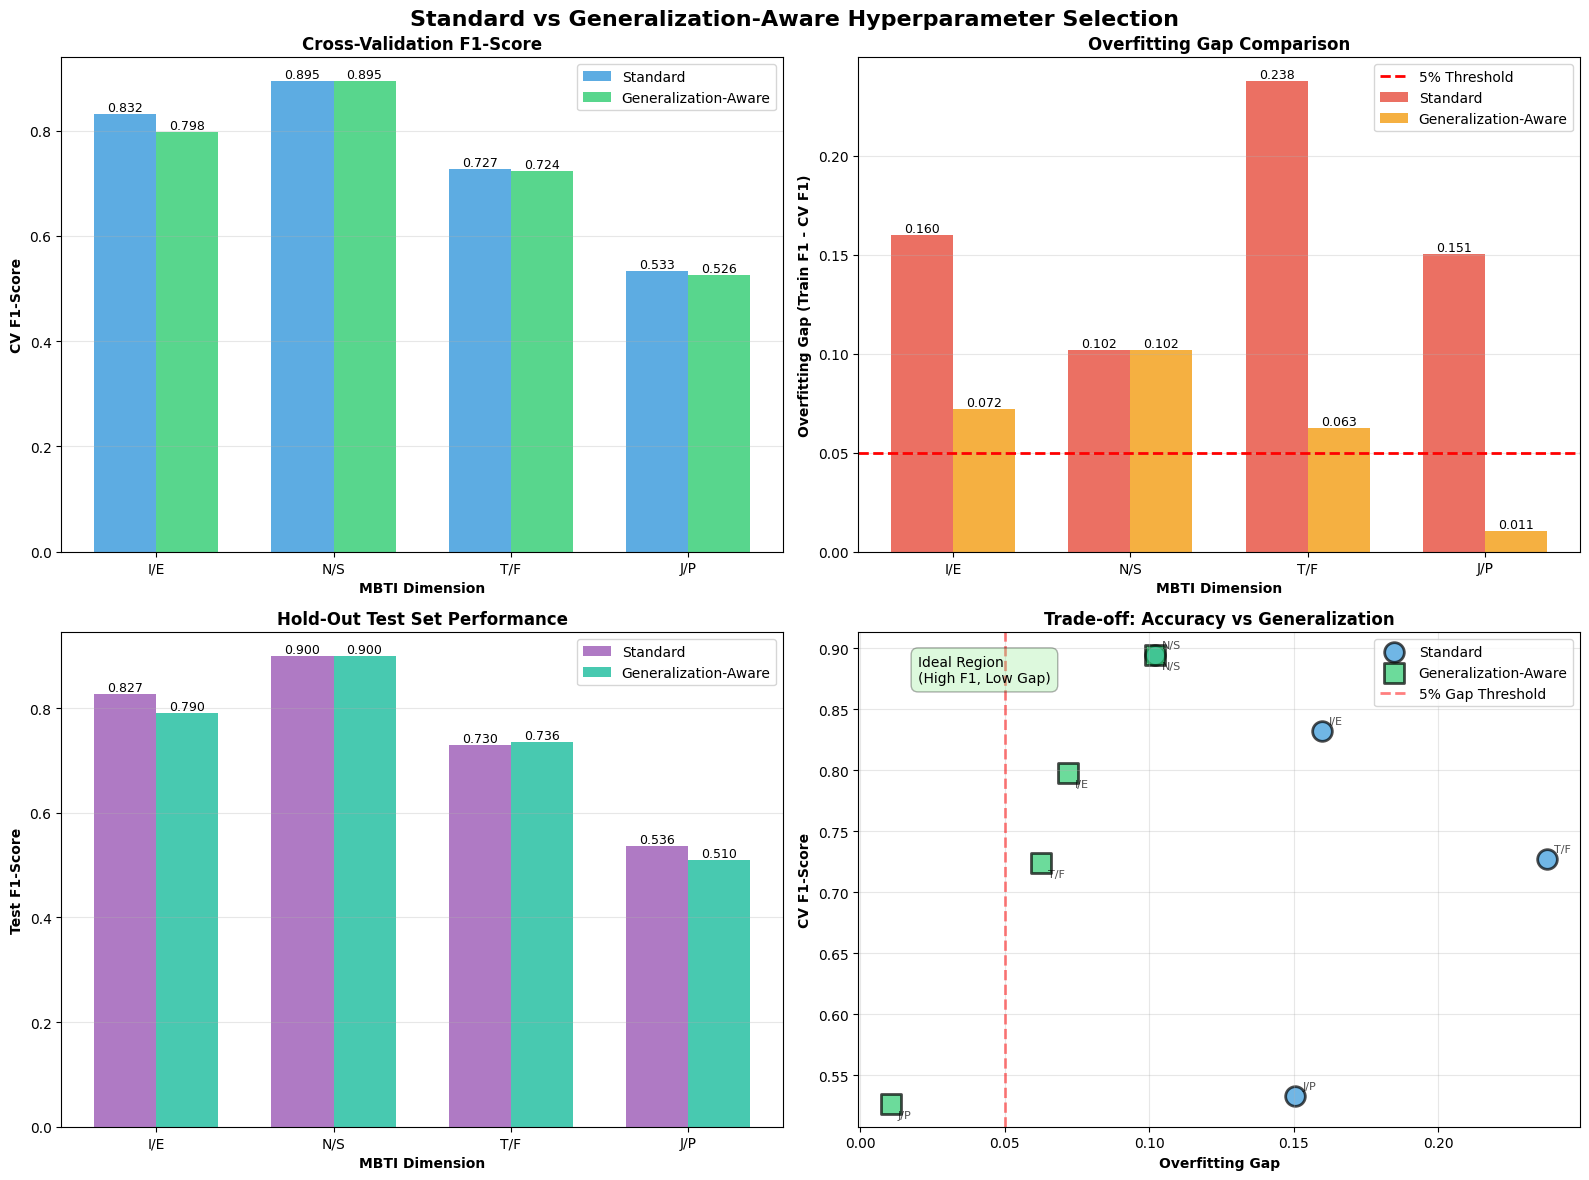


📊 Visualization complete: Standard vs Generalization-Aware approaches


In [19]:
# Visualization: Standard vs Generalization-Aware
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Standard vs Generalization-Aware Hyperparameter Selection', fontsize=16, fontweight='bold')

dimensions_list = list(dimensions.keys())

# Plot 1: CV F1-Score Comparison
ax1 = axes[0, 0]
x = np.arange(len(dimensions_list))
width = 0.35

standard_cv_scores = [comparison_df[comparison_df['dimension'] == dim]['standard_cv_f1'].mean() for dim in dimensions_list]
gen_cv_scores = [comparison_df[comparison_df['dimension'] == dim]['gen_cv_f1'].mean() for dim in dimensions_list]

bars1 = ax1.bar(x - width/2, standard_cv_scores, width, label='Standard', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, gen_cv_scores, width, label='Generalization-Aware', color='#2ecc71', alpha=0.8)

ax1.set_xlabel('MBTI Dimension', fontweight='bold')
ax1.set_ylabel('CV F1-Score', fontweight='bold')
ax1.set_title('Cross-Validation F1-Score', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(dimensions_list)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Overfitting Gap Comparison
ax2 = axes[0, 1]

standard_gaps = [comparison_df[comparison_df['dimension'] == dim]['standard_overfit_gap'].mean() for dim in dimensions_list]
gen_gaps = [comparison_df[comparison_df['dimension'] == dim]['gen_overfit_gap'].mean() for dim in dimensions_list]

bars3 = ax2.bar(x - width/2, standard_gaps, width, label='Standard', color='#e74c3c', alpha=0.8)
bars4 = ax2.bar(x + width/2, gen_gaps, width, label='Generalization-Aware', color='#f39c12', alpha=0.8)

ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='5% Threshold')
ax2.set_xlabel('MBTI Dimension', fontweight='bold')
ax2.set_ylabel('Overfitting Gap (Train F1 - CV F1)', fontweight='bold')
ax2.set_title('Overfitting Gap Comparison', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(dimensions_list)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 3: Test F1-Score Comparison
ax3 = axes[1, 0]

standard_test_scores = [comparison_df[comparison_df['dimension'] == dim]['standard_test_f1'].mean() for dim in dimensions_list]
gen_test_scores = [comparison_df[comparison_df['dimension'] == dim]['gen_test_f1'].mean() for dim in dimensions_list]

bars5 = ax3.bar(x - width/2, standard_test_scores, width, label='Standard', color='#9b59b6', alpha=0.8)
bars6 = ax3.bar(x + width/2, gen_test_scores, width, label='Generalization-Aware', color='#1abc9c', alpha=0.8)

ax3.set_xlabel('MBTI Dimension', fontweight='bold')
ax3.set_ylabel('Test F1-Score', fontweight='bold')
ax3.set_title('Hold-Out Test Set Performance', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(dimensions_list)
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars5, bars6]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 4: Trade-off Scatter Plot
ax4 = axes[1, 1]

# For each approach, plot CV score vs overfitting gap
ax4.scatter(standard_gaps, standard_cv_scores, s=200, c='#3498db', marker='o', 
           alpha=0.7, label='Standard', edgecolors='black', linewidths=2)
ax4.scatter(gen_gaps, gen_cv_scores, s=200, c='#2ecc71', marker='s', 
           alpha=0.7, label='Generalization-Aware', edgecolors='black', linewidths=2)

# Add dimension labels
for i, dim in enumerate(dimensions_list):
    # Standard
    ax4.annotate(dim, (standard_gaps[i], standard_cv_scores[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)
    # Generalization-aware
    ax4.annotate(dim, (gen_gaps[i], gen_cv_scores[i]), 
                xytext=(5, -10), textcoords='offset points', fontsize=8, alpha=0.7)

ax4.axvline(x=0.05, color='red', linestyle='--', linewidth=2, alpha=0.5, label='5% Gap Threshold')
ax4.set_xlabel('Overfitting Gap', fontweight='bold')
ax4.set_ylabel('CV F1-Score', fontweight='bold')
ax4.set_title('Trade-off: Accuracy vs Generalization', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# Add ideal region annotation
ax4.annotate('Ideal Region\n(High F1, Low Gap)', 
            xy=(0.02, max(gen_cv_scores)), 
            fontsize=10, ha='left', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n📊 Visualization complete: Standard vs Generalization-Aware approaches")

## 🎯 Key Insights from Generalization-Aware Selection

**What We Did:**
- Compared standard hyperparameter selection (max CV F1) with generalization-aware selection
- Generalization score = CV F1 - penalty × overfitting gap (penalty = 0.5)
- Evaluated both approaches on hold-out test set

**Expected Outcomes:**
1. **Generalization-aware models should have:**
   - Slightly lower CV F1-score (sacrifice some training performance)
   - Significantly lower overfitting gap (better generalization)
   - Similar or better test F1-score (more robust to new data)

2. **When different hyperparameters are selected:**
   - Generalization-aware typically chooses stronger regularization (lower C)
   - May prefer balanced class weights over optimizing for minority class
   - Trades peak performance for consistency

**When to Use Each Approach:**
- **Standard (Max CV F1):** When deploying to similar data distribution, maximize accuracy
- **Generalization-Aware:** When deploying to new/unknown data, prioritize robustness
- **Recommendation for production:** Generalization-aware with penalty 0.3-0.5